# 04 — Black–Scholes: Rho por Pathwise vs. Diferencias Finitas

**Objetivo del notebook.** Comparar dos estimadores Monte Carlo de la $\rho$ de una opción europea bajo Black–Scholes:

1. **Pathwise (PW):** estimador obtenido derivando el payoff descontado respecto a $r$ bajo la esperanza.
2. **Diferencias Finitas centradas (FD)** con CRN.

A diferencia de Delta y Vega, $r$ aparece simultáneamente en **dos lugares** del estimador: en el factor de descuento $e^{-rT}$ y en el drift de la dinámica $S_T = S_0 \exp\!\bigl((r - \tfrac{1}{2}\sigma^2)T + \sigma W_T\bigr)$. La derivación pathwise es un poco más compleja, hay que derivar en los dos términos:

$$\frac{\partial}{\partial r}\bigl[e^{-rT}(S_T - K)^+\bigr] = -T e^{-rT}(S_T - K)^+ + e^{-rT} \mathbf{1}_{S_T > K}\,\frac{\partial S_T}{\partial r}.$$

Como $\partial S_T / \partial r = T S_T$, el estimador final para una call europea es:

$$\rho^{PW} = e^{-rT}\, \mathbb{E}\!\left[T\,\mathbf{1}_{S_T > K}\,S_T \;-\; T\,(S_T - K)^+\right], \qquad \rho^{FD} = \frac{V(r+h) - V(r-h)}{2h}.$$

> **Nota de notación.** $\rho$ designa exclusivamente la Griega (sensibilidad respecto a $r$). No debe confundirse con $\rho_h$ (correlación entre simulaciones perturbadas en CRN) ni con $\rho_{S,r}$ (correlación browniana en el modelo de Hull–White, Cap. 4).

> **Implementación FD.** Al perturbar $r \to r \pm h$, hay que perturbar **ambos** lugares de forma consistente: el drift en `GeneratePathsGBM_givenZ` y el factor de descuento en el estimador de precio.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs_utils import (BS_rho,GeneratePathsGBM_givenZ,PathwiseRho,FD_Rho)

np.set_printoptions(suppress=True, precision=6)


## 1. Parámetros del experimento


In [2]:
CP        = 'call'
S0        = 100.0
K         = 100.0
sigma     = 0.20
r         = 0.05
T         = 1.0
t         = 0.0
NoOfSteps = 1            # simulación en un único paso (exacta para BS)

SEED      = 3


## 2. Validación puntual

Generamos una matriz $Z$ de $\mathcal{N}(0,1)$ y la reutilizamos para PW y FD, garantizando CRN entre las perturbaciones  $r \pm h$.


In [3]:
N = 100_000
h = 0.001          

rng = np.random.default_rng(SEED)
Z = rng.normal(0.0, 1.0, (N, NoOfSteps))

paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)

rho_BS = BS_rho(CP, S0, K, sigma, t, T, r)
rho_PW = PathwiseRho(CP, S0, paths["S"], K, r, T)
rho_FD = FD_Rho(CP, S0, K, sigma, T, r, h, Z)

print(f"Rho BS (analítica): {rho_BS:.6f}")
print(f"Rho PW (pathwise):  {rho_PW:.6f}    error abs = {abs(rho_PW - rho_BS):.2e}")
print(f"Rho FD (centrada):  {rho_FD:.6f}    error abs = {abs(rho_FD - rho_BS):.2e}")


Rho BS (analítica): 53.232482
Rho PW (pathwise):  53.156603    error abs = 7.59e-02
Rho FD (centrada):  53.154129    error abs = 7.84e-02


**Lectura.** Ambos estimadores reproducen la $\rho$ analítica con errores comparables. El estimador PW recoge directamente los dos términos (descuento y drift) en una única esperanza, sin perturbación numérica.

Los errores son similares entre PW y FD para Rho son esperables: el payoff de la call es suave respecto a r (diferenciable en todo punto donde importa), así que ambos métodos convergen sin problemas.

## 3. Convergencia frente a $N$

Tasa esperada $\mathcal{O}(N^{-1/2})$ para ambos estimadores (Monte Carlo estándar).


In [8]:
N_list = [1000, 5000, 10000, 50000, 100000]
results = []

rng = np.random.default_rng(SEED)

for N in N_list:
    Z = rng.normal(0.0, 1.0, (N, NoOfSteps))
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    
    rho_PW = PathwiseRho(CP, S0, paths["S"], K, r, T)
    rho_FD = FD_Rho(CP, S0, K, sigma, T, r, h, Z)
    
    results.append([
        N,
        rho_PW, abs(rho_PW - rho_BS),
        rho_FD, abs(rho_FD - rho_BS),
        1.0/np.sqrt(N)
    ])

df_N = pd.DataFrame(results, columns=[
    "N", "Rho_PW", "Error_PW", "Rho_FD", "Error_FD", "MC_rate"
])
df_N


,N,Rho_PW,Error_PW,Rho_FD,Error_FD,MC_rate
0,1000,53.839585,0.607104,53.756411,0.523930,0.031623
1,5000,53.478118,0.245637,53.474470,0.241988,0.014142
2,10000,52.859819,0.372662,52.875549,0.356933,0.010000
3,50000,53.280263,0.047781,53.276391,0.043909,0.004472
4,100000,53.148042,0.084440,53.165424,0.067058,0.003162


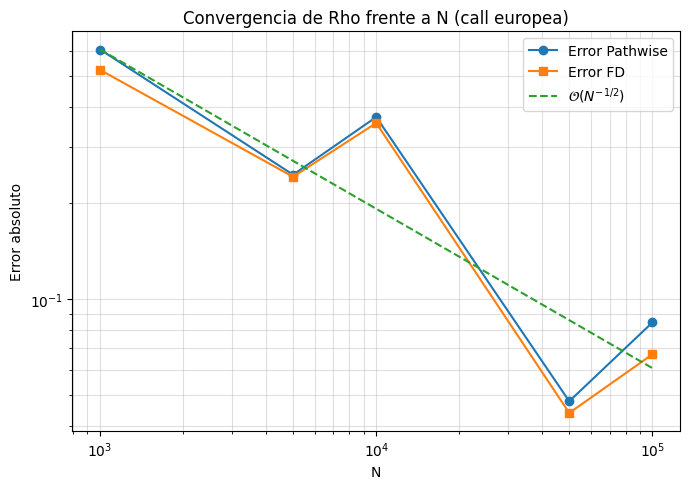

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_N["N"], df_N["Error_PW"], "o-", label="Error Pathwise")
ax.loglog(df_N["N"], df_N["Error_FD"], "s-", label="Error FD")
# Reescalado de 1/sqrt(N) al primer punto para referencia visual
scale = df_N["Error_PW"].iloc[0] * np.sqrt(df_N["N"].iloc[0])
ax.loglog(df_N["N"], scale/np.sqrt(df_N["N"]), "--",
          label=r"$\mathcal{O}(N^{-1/2})$")
ax.set_xlabel("N")
ax.set_ylabel("Error absoluto")
ax.set_title("Convergencia de Rho frente a N (call europea)")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


**Lectura.** Convergencia $\mathcal{O}(N^{-1/2})$ confirmada para ambos estimadores. La precisión es bastante similar.

## 4. Estabilidad estadística: varianza del estimador

Replicaciones independientes para comparar dispersión empírica de PW y FD.


In [10]:
def estimadores_rho(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h, rng):
    """Devuelve (rho_PW, rho_FD) usando CRN   """
    Z = rng.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))
    
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    rho_PW = PathwiseRho(CP, S0, paths["S"], K, r, T)
    rho_FD = FD_Rho(CP, S0, K, sigma, T, r, h, Z)
    
    return rho_PW, rho_FD


In [11]:
N_list = [1000, 5000, 10000, 50000]
M = 100

rng = np.random.default_rng(SEED)
results_var = []

for N in N_list:
    pw_vals = np.empty(M)
    fd_vals = np.empty(M)
    
    for j in range(M):
        rho_PW, rho_FD = estimadores_rho(
            CP, S0, K, r, T, sigma, N, NoOfSteps, h, rng
        )
        pw_vals[j] = rho_PW
        fd_vals[j] = rho_FD
    
    results_var.append([
        N,
        np.mean(pw_vals), np.var(pw_vals, ddof=1), np.std(pw_vals, ddof=1),
        np.mean(fd_vals), np.var(fd_vals, ddof=1), np.std(fd_vals, ddof=1),
    ])

df_var = pd.DataFrame(results_var, columns=[
    "N",
    "Mean_PW", "Var_PW", "Std_PW",
    "Mean_FD", "Var_FD", "Std_FD"
])
df_var


,N,Mean_PW,Var_PW,Std_PW,Mean_FD,Var_FD,Std_FD
0,1000,53.112846,0.738954,0.859624,53.117004,0.712428,0.844055
1,5000,53.233082,0.196266,0.443019,53.233737,0.197724,0.444661
2,10000,53.266470,0.076998,0.277485,53.265914,0.075604,0.274962
3,50000,53.230437,0.017886,0.133738,53.229854,0.017391,0.131874


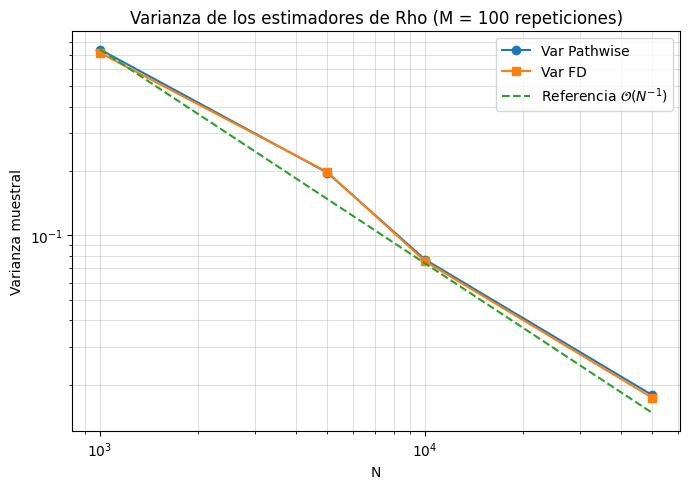

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_var["N"], df_var["Var_PW"], "o-", label="Var Pathwise")
ax.loglog(df_var["N"], df_var["Var_FD"], "s-", label="Var FD")

scale = df_var["Var_PW"].iloc[0] * df_var["N"].iloc[0]
ax.loglog(df_var["N"], scale / df_var["N"], "--",
          label=r"Referencia $\mathcal{O}(N^{-1})$")


ax.set_xlabel("N")
ax.set_ylabel("Varianza muestral")
ax.set_title(f"Varianza de los estimadores de Rho (M = {M} repeticiones)")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


**Lectura.** Varianza decreciente a tasa $1/N$ para ambos estimadores. Las dispersiones son comparables, con una varianza absoluta de $\rho$ mayor que la de Delta y Vega por la presencia del factor $T$ multiplicando $S_T$ en los integrandos.


## 5. Sensibilidad respecto al paso $h$

Como en Delta y Vega, el estimador pathwise no depende de $h$; el FD presenta el compromiso sesgo–varianza habitual con sesgo $\mathcal{O}(h^2)$ y varianza inflada por $1/h^2$ a $h \to 0$.


In [14]:
h_list = [0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
N_h = 10000
M_h = 200

rng = np.random.default_rng(SEED)

pw_all = np.empty(M_h)
fd_all = {h_val: np.empty(M_h) for h_val in h_list}

for j in range(M_h):
    Z = rng.normal(0.0, 1.0, (N_h, NoOfSteps))
    
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    pw_all[j] = PathwiseRho(CP, S0, paths["S"], K, r, T)
    
    for h_val in h_list:
        fd_all[h_val][j] = FD_Rho(CP, S0, K, sigma, T, r, h_val, Z)

mean_pw = np.mean(pw_all);    var_pw = np.var(pw_all, ddof=1)
bias_pw = mean_pw - rho_BS;   mse_pw = var_pw + bias_pw**2

rows = []
for h_val in h_list:
    fd_v = fd_all[h_val]
    mean_fd = np.mean(fd_v); var_fd = np.var(fd_v, ddof=1)
    bias_fd = mean_fd - rho_BS; mse_fd = var_fd + bias_fd**2
    rows.append([
        h_val,
        mean_pw, bias_pw, abs(bias_pw), var_pw, mse_pw,
        mean_fd, bias_fd, abs(bias_fd), var_fd, mse_fd
    ])

df_h = pd.DataFrame(rows, columns=[
    "h",
    "Mean_PW", "Bias_PW", "AbsBias_PW", "Var_PW", "MSE_PW",
    "Mean_FD", "Bias_FD", "AbsBias_FD", "Var_FD", "MSE_FD"
])
df_h


,h,Mean_PW,Bias_PW,AbsBias_PW,Var_PW,MSE_PW,Mean_FD,Bias_FD,AbsBias_FD,Var_FD,MSE_FD
0,0.0500,53.247207,0.014726,0.014726,0.07994,0.080157,53.055161,-0.177321,0.177321,0.052965,0.084407
1,0.0100,53.247207,0.014726,0.014726,0.07994,0.080157,53.240180,0.007699,0.007699,0.073141,0.073200
2,0.0050,53.247207,0.014726,0.014726,0.07994,0.080157,53.246400,0.013918,0.013918,0.075504,0.075698
3,0.0010,53.247207,0.014726,0.014726,0.07994,0.080157,53.247690,0.015209,0.015209,0.078521,0.078753
4,0.0005,53.247207,0.014726,0.014726,0.07994,0.080157,53.247612,0.015130,0.015130,0.079161,0.079390
5,0.0001,53.247207,0.014726,0.014726,0.07994,0.080157,53.247018,0.014536,0.014536,0.079241,0.079453


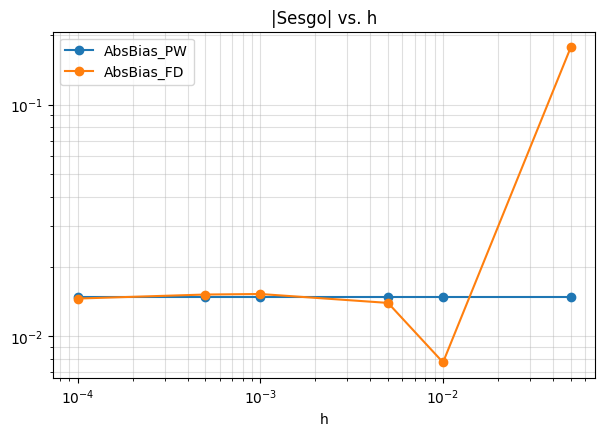

In [15]:
df_h.plot(x="h", y=["AbsBias_PW", "AbsBias_FD"], logx=True, logy=True,
          marker="o", figsize=(7,4.5), title="|Sesgo| vs. h").grid(True, which="both", alpha=0.4)
plt.show()


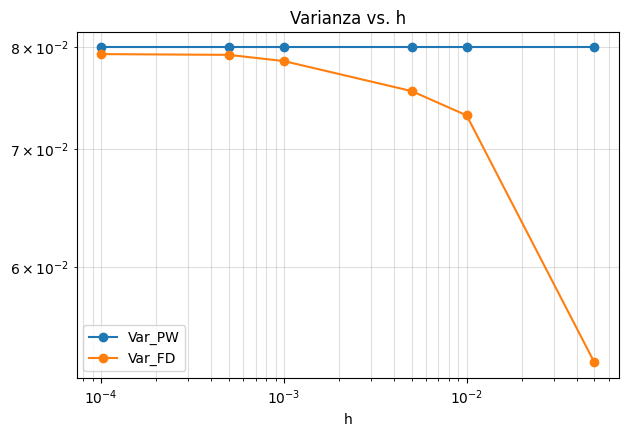

In [16]:
df_h.plot(x="h", y=["Var_PW", "Var_FD"], logx=True, logy=True,
          marker="o", figsize=(7,4.5), title="Varianza vs. h").grid(True, which="both", alpha=0.4)
plt.show()


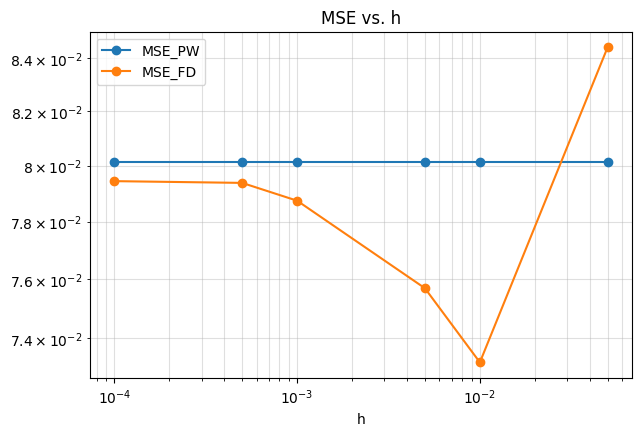

In [17]:
df_h.plot(x="h", y=["MSE_PW", "MSE_FD"], logx=True, logy=True,
          marker="o", figsize=(7,4.5), title="MSE vs. h").grid(True, which="both", alpha=0.4)
plt.show()


**Lectura.** 

- **Pathwise.** Estadísticas constantes en $h$ (líneas horizontales): el estimador no se construye por perturbación.
- **FD.** El sesgo decrece como $h^2$ para $h$ moderado, en el sesgo vemos el ruido Monte Carlo de la estimación, lo que produce las fluctuaciones aleatorias observadas; la varianza se mantiene aproximadamente constante en el rango intermedio gracias al CRN, pero crece a $h \to 0$ por amplificación numérica del factor $1/(2h)^2$.
- **MSE.** Curva en U para FD; el mínimo identifica el $h^\star$ óptimo de FD para la $\rho$ ATM en este escenario.



## 6. Conclusiones del notebook

1. PW y FD reproducen la $\rho$ analítica con tasa $\mathcal{O}(N^{-1/2})$ y precisión comparable bajo CRN.
2. El estimador pathwise para $\rho$ tiene **dos términos** —descuento y drift— por la doble dependencia de $r$. Este patrón lo vemos en toda Griega que afecte simultáneamente al factor de descuento y a la dinámica del subyacente.
3. La **independencia respecto a $h$** del estimador PW vuelve a ser la ventaja operativa principal: no requiere calibración del paso de perturbación.
